# Преобразование типов и изменение формы данных

**Решение преподавателя. Продолжительность: 90 минут.**

Работа выполняется на реальном файле `MoviesOnStreamingPlatforms.csv`. Одна строка исходной таблицы описывает один фильм, а четыре бинарных поля показывают наличие фильма на стриминговых платформах.

**Источник датасета:** [https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv](https://github.com/Swapnajacontribution/Datasets/blob/main/MoviesOnStreamingPlatforms.csv)


Результаты пары:

- подготовленная таблица фильмов;
- новые аналитические признаки;
- переход из широкого формата в длинный через `melt`;
- обратная проверка через `pivot`;
- диагностические графики;
- файлы `movies_clean.csv` и `movies_long.csv`.

In [1]:
# -----------------------------------------------------------------------------
# Назначение ячейки: подготовить воспроизводимое окружение для дальнейшей работы.
# Здесь подключаются библиотеки, выводятся версии Python/pandas/NumPy и определяется
# корневая папка проекта. Поиск корня сделан специально так, чтобы notebook можно
# было запускать из VS Code, Jupyter и Google Colab без изменения путей вручную.
# Результат ячейки: переменные PROJECT_ROOT, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR и DATA_PATH.
# -----------------------------------------------------------------------------

from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем, выполняется ли notebook в Google Colab.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Python:", sys.version.split()[0])
print("Операционная система:", platform.system())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Google Colab:", IN_COLAB)
print("Текущая рабочая папка:", Path.cwd())


def find_project_root() -> Path:
    """Ищет папку пары по наличию исходного CSV.

    Функция позволяет запускать notebook:
    - из корня папки пары;
    - из подпапки notebooks в VS Code или Jupyter;
    - в Google Colab после распаковки папки пары в /content.
    """
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    marker = Path("data/raw/MoviesOnStreamingPlatforms.csv")
    for candidate in candidates:
        if (candidate / marker).exists():
            return candidate

    # Дополнительные типовые расположения для Google Colab.
    colab_candidates = [
        Path('/content'),
        Path('/content/01_types_and_reshape'),
        Path('/content/02_aggregation_and_datamart'),
        Path('/content/03_scaling_methods'),
        Path('/content/04_reproducible_preprocessing'),
    ]
    for candidate in colab_candidates:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Не найден data/raw/MoviesOnStreamingPlatforms.csv. "
        "Распакуйте архив пары целиком и запустите notebook повторно."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "MoviesOnStreamingPlatforms.csv"
print("Корень проекта:", PROJECT_ROOT)
print("Исходный файл:", DATA_PATH)

Python: 3.10.5
Операционная система: Windows
pandas: 2.0.1
NumPy: 1.23.5
Google Colab: False
Текущая рабочая папка: d:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.3.1 Преобразование данных\notebooks
Корень проекта: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.3.1 Преобразование данных
Исходный файл: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.3.1 Преобразование данных\data\raw\MoviesOnStreamingPlatforms.csv


> **Комментарий преподавателю.** Контрольные значения исходного файла: 9515 строк и 11 столбцов. Пропуски сосредоточены прежде всего в `Age`, а `Type` принимает только значение 0. Обратите внимание слушателей, что `ID` — идентификатор, а не количественный аналитический признак.

## 1. Загрузка и первичная диагностика

До преобразований проверяем размер, названия полей, типы, пропуски и уникальность идентификатора. Это помогает отличить технические столбцы от содержательных признаков.

In [2]:
# -----------------------------------------------------------------------------
# Назначение ячейки: загрузить исходный CSV и провести первичную диагностику.
# Проверяем размер таблицы, первые строки, типы данных, пропуски, полные дубликаты
# и уникальность идентификатора фильма. Это позволяет увидеть проблемы до того,
# как мы начнем преобразования, и затем сравнить состояние данных после обработки.
# Вход: DATA_PATH. Выход: DataFrame movies_raw.
# -----------------------------------------------------------------------------

movies_raw = pd.read_csv(DATA_PATH)

print("Размер исходной таблицы:", movies_raw.shape)
display(movies_raw.head())
print("\nТипы данных:")
display(movies_raw.dtypes.to_frame("dtype"))
print("\nПропуски:")
display(movies_raw.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("\nПолных дубликатов строк:", movies_raw.duplicated().sum())
print("Уникальных ID:", movies_raw["ID"].nunique())

Размер исходной таблицы: (9515, 11)


,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0



Типы данных:


,dtype
Unnamed: 0,int64
ID,int64
Title,object
Year,int64
Age,object
Rotten Tomatoes,object
Netflix,int64
Hulu,int64
Prime Video,int64
Disney+,int64



Пропуски:


,missing
Age,4177
Rotten Tomatoes,7
Unnamed: 0,0
ID,0
Title,0
Year,0
Netflix,0
Hulu,0
Prime Video,0
Disney+,0



Полных дубликатов строк: 0
Уникальных ID: 9515


## 2. Преобразование типов и создание признаков

Ключевые действия:

1. удаление технического индекса;
2. преобразование строкового рейтинга `98/100` в число;
3. нормализация возрастной категории;
4. создание возраста фильма, десятилетия, длины названия и количества платформ.

In [3]:
# -----------------------------------------------------------------------------
# Назначение ячейки: описать все преобразования в одной функции prepare_movies().
# Функция работает с копией входного DataFrame, поэтому исходные данные не меняются.
# Внутри удаляется технический индекс, переименовываются столбцы, преобразуются
# рейтинг и год выпуска, нормализуются возрастные категории и создаются новые признаки.
# Выход функции: подготовленная таблица с понятными именами и аналитическими признаками.
# -----------------------------------------------------------------------------

def prepare_movies(df: pd.DataFrame) -> pd.DataFrame:
    """Подготавливает каталог фильмов для анализа.

    Параметры
    ---------
    df : pd.DataFrame
        Исходная таблица без предварительного изменения.

    Возвращает
    ----------
    pd.DataFrame
        Новую таблицу с приведенными типами и производными признаками.
    """
    # Создаем независимую копию, чтобы функция не изменяла исходный DataFrame.
    result = df.copy()

    # Удаляем технический индекс, который был записан в исходный CSV.
    if "Unnamed: 0" in result.columns:
        result = result.drop(columns=["Unnamed: 0"])

    # Переименовываем поля, чтобы с ними было удобнее работать в Python.
    result = result.rename(columns={
        "ID": "movie_id",
        "Title": "title",
        "Year": "release_year",
        "Age": "age_rating",
        "Rotten Tomatoes": "rating_score",
        "Prime Video": "Prime_Video",
        "Disney+": "Disney_Plus",
        "Type": "type_code",
    })

    # Рейтинг вида "98/100" преобразуем в число 98.
    result["rating_score"] = pd.to_numeric(
        result["rating_score"].astype("string").str.replace("/100", "", regex=False),
        errors="coerce",
    )
    # errors="coerce" превращает некорректные значения в NaN, а nullable-тип Int64
    # позволяет хранить целые годы вместе с возможными пропусками.
    result["release_year"] = pd.to_numeric(result["release_year"], errors="coerce").astype("Int64")

    # Приводим возрастные категории к единому виду.
    result["age_rating"] = (
        result["age_rating"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"all": "0+", "<na>": "unknown"})
        .fillna("unknown")
    )

    # Создаем признаки, которые понадобятся в следующих частях занятия.
    # Фиксированный опорный год делает расчет воспроизводимым: результат не меняется
    # автоматически при запуске notebook в другом календарном году.
    reference_year = 2026
    result["movie_age"] = reference_year - result["release_year"].astype("float64")
    result["decade"] = (result["release_year"].astype("float64") // 10 * 10).astype("Int64")
    result["title_length"] = result["title"].astype("string").str.len().astype("Int64")

    platform_columns = ["Netflix", "Hulu", "Prime_Video", "Disney_Plus"]
    # Так как платформенные столбцы содержат 0/1, сумма по строке равна числу
    # сервисов, на которых доступен конкретный фильм.
    result["platform_count"] = result[platform_columns].sum(axis=1).astype("int64")
    result["availability_group"] = np.where(
        result["platform_count"].gt(1), "multi_platform", "single_platform"
    )

    result["rating_band"] = pd.cut(
        result["rating_score"],
        bins=[0, 49, 64, 79, 100],
        labels=["низкий", "средний", "высокий", "очень высокий"],
        include_lowest=True,
    ).astype("string")

    # Преобразуем понятную человеку маркировку в числовой минимальный возраст.
    # Категория unknown останется пропуском: ей нельзя приписывать выдуманный возраст.
    age_map = {"0+": 0, "7+": 7, "13+": 13, "16+": 16, "18+": 18}
    result["age_min"] = result["age_rating"].map(age_map).astype("float64")
    return result

In [4]:
# -----------------------------------------------------------------------------
# Назначение ячейки: применить функцию подготовки и проверить результат.
# После преобразования выводятся первые строки и типы ключевых признаков.
# Инструкции assert выполняют роль автоматических контрольных точек: если нарушена
# уникальность ID, диапазон рейтинга или число платформ, выполнение остановится сразу.
# Вход: movies_raw. Выход: DataFrame movies.
# -----------------------------------------------------------------------------

movies = prepare_movies(movies_raw)

print("Размер после подготовки:", movies.shape)
display(movies.head())
print("\nТипы ключевых полей:")
display(
    movies[["release_year", "rating_score", "movie_age", "title_length", "platform_count"]]
    .dtypes
    .to_frame("dtype")
)

# Автоматические проверки помогают быстро обнаружить ошибку в преобразованиях.
assert len(movies) == len(movies_raw)
assert movies["movie_id"].is_unique
assert movies["platform_count"].between(1, 4).all()
assert movies["rating_score"].dropna().between(0, 100).all()

Размер после подготовки: (9515, 17)


,movie_id,title,release_year,age_rating,rating_score,Netflix,Hulu,Prime_Video,Disney_Plus,type_code,movie_age,decade,title_length,platform_count,availability_group,rating_band,age_min
0,1,The Irishman,2019,18+,98,1,0,0,0,0,7.0,2010,12,1,single_platform,очень высокий,18.0
1,2,Dangal,2016,7+,97,1,0,0,0,0,10.0,2010,6,1,single_platform,очень высокий,7.0
2,3,David Attenborough: A Life on Our Planet,2020,7+,95,1,0,0,0,0,6.0,2020,40,1,single_platform,очень высокий,7.0
3,4,Lagaan: Once Upon a Time in India,2001,7+,94,1,0,0,0,0,25.0,2000,33,1,single_platform,очень высокий,7.0
4,5,Roma,2018,18+,94,1,0,0,0,0,8.0,2010,4,1,single_platform,очень высокий,18.0



Типы ключевых полей:


,dtype
release_year,Int64
rating_score,Int64
movie_age,float64
title_length,Int64
platform_count,int64


## 3. Визуальная диагностика результатов

Графики используются как контроль преобразований. Мы не разбираем дизайн визуализации подробно: это будет отдельной темой курса.

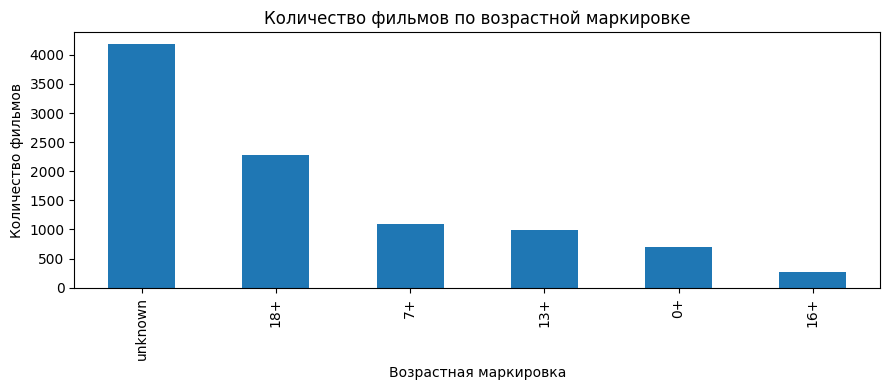

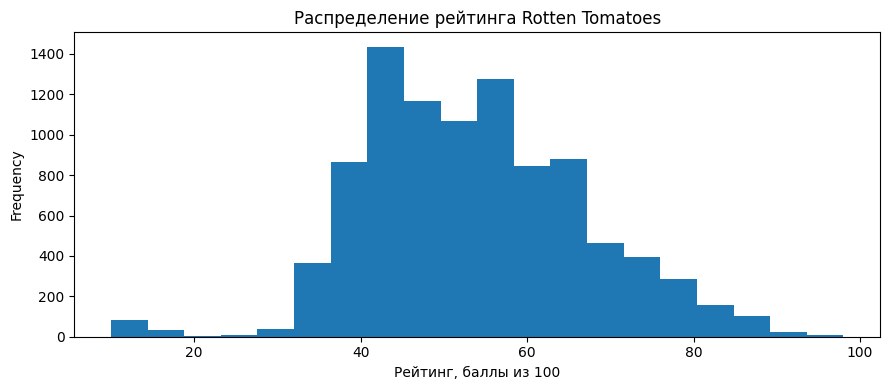

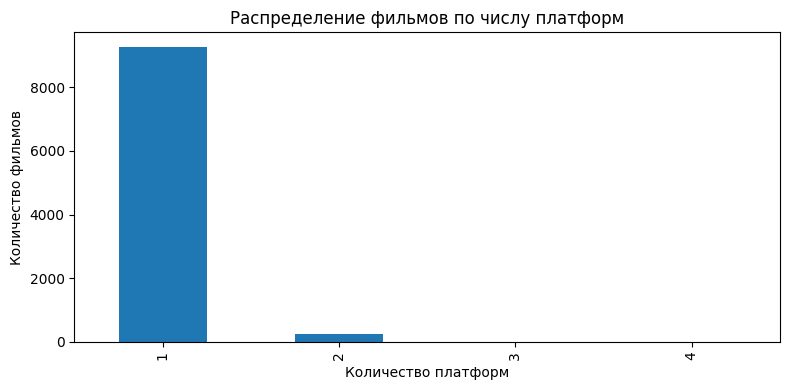

In [5]:
# -----------------------------------------------------------------------------
# Назначение ячейки: визуально проверить результаты преобразований.
# Столбчатые диаграммы показывают категориальные распределения, а гистограмма —
# распределение числового рейтинга. Каждый график не только отображается в notebook,
# но и сохраняется в папку outputs, чтобы его можно было использовать в отчете.
# Вход: movies. Выход: три PNG-файла и диагностические графики на экране.
# -----------------------------------------------------------------------------

# Распределение возрастных маркировок после нормализации.
age_counts = movies["age_rating"].value_counts(dropna=False).sort_values(ascending=False)
ax = age_counts.plot(kind="bar", figsize=(9, 4), title="Количество фильмов по возрастной маркировке")
ax.set_xlabel("Возрастная маркировка")
ax.set_ylabel("Количество фильмов")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_rating_distribution.png", dpi=140)
plt.show()

# Распределение числового рейтинга после преобразования строк.
ax = movies["rating_score"].plot(kind="hist", bins=20, figsize=(9, 4), title="Распределение рейтинга Rotten Tomatoes")
ax.set_xlabel("Рейтинг, баллы из 100")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rating_distribution.png", dpi=140)
plt.show()

# Проверяем новый признак количества платформ.
platform_count_distribution = movies["platform_count"].value_counts().sort_index()
ax = platform_count_distribution.plot(kind="bar", figsize=(8, 4), title="Распределение фильмов по числу платформ")
ax.set_xlabel("Количество платформ")
ax.set_ylabel("Количество фильмов")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "platform_count_distribution.png", dpi=140)
plt.show()

## 4. Широкий и длинный формат: `melt`

В исходной таблице каждая платформа находится в отдельной колонке. После `melt` названия платформ становятся значениями одного столбца `platform`. Одна строка длинной таблицы означает: **один фильм доступен на одной платформе**.

In [6]:
# -----------------------------------------------------------------------------
# Назначение ячейки: перевести платформенные признаки из широкого формата в длинный.
# В исходной таблице каждая платформа является отдельным столбцом 0/1. Метод melt()
# превращает эти столбцы в две переменные: platform и available. После этого оставляем
# только строки available == 1, то есть реальные связи «фильм — платформа».
# Контроль: число строк длинной таблицы должно совпасть с суммой всех единиц платформ.
# -----------------------------------------------------------------------------

platform_columns = ["Netflix", "Hulu", "Prime_Video", "Disney_Plus"]

movies_long = movies.melt(
    id_vars=[
        "movie_id", "title", "release_year", "age_rating", "rating_score",
        "movie_age", "decade", "title_length", "platform_count",
        "availability_group", "rating_band", "age_min",
    ],
    value_vars=platform_columns,
    var_name="platform",
    value_name="available",
)

# Оставляем только реальные связи фильма с платформой.
movies_long = movies_long.loc[movies_long["available"].eq(1)].reset_index(drop=True)
movies_long["platform"] = movies_long["platform"].replace({
    "Prime_Video": "Prime Video",
    "Disney_Plus": "Disney+",
})

display(movies_long.head(10))
print("Строк в длинной таблице:", len(movies_long))
print("Сумма всех единиц в исходных платформенных колонках:", int(movies[platform_columns].to_numpy().sum()))

assert len(movies_long) == int(movies[platform_columns].to_numpy().sum())

,movie_id,title,release_year,age_rating,rating_score,movie_age,decade,title_length,platform_count,availability_group,rating_band,age_min,platform,available
0,1,The Irishman,2019,18+,98,7.0,2010,12,1,single_platform,очень высокий,18.0,Netflix,1
1,2,Dangal,2016,7+,97,10.0,2010,6,1,single_platform,очень высокий,7.0,Netflix,1
2,3,David Attenborough: A Life on Our Planet,2020,7+,95,6.0,2020,40,1,single_platform,очень высокий,7.0,Netflix,1
3,4,Lagaan: Once Upon a Time in India,2001,7+,94,25.0,2000,33,1,single_platform,очень высокий,7.0,Netflix,1
4,5,Roma,2018,18+,94,8.0,2010,4,1,single_platform,очень высокий,18.0,Netflix,1
5,6,To All the Boys I've Loved Before,2018,13+,94,8.0,2010,33,1,single_platform,очень высокий,13.0,Netflix,1
6,7,The Social Dilemma,2020,13+,93,6.0,2020,18,1,single_platform,очень высокий,13.0,Netflix,1
7,8,Okja,2017,13+,92,9.0,2010,4,1,single_platform,очень высокий,13.0,Netflix,1
8,9,The Ballad of Buster Scruggs,2018,16+,92,8.0,2010,28,1,single_platform,очень высокий,16.0,Netflix,1
9,10,The Trial of the Chicago 7,2020,18+,92,6.0,2020,26,1,single_platform,очень высокий,18.0,Netflix,1


Строк в длинной таблице: 9777
Сумма всех единиц в исходных платформенных колонках: 9777


## 5. Обратная проверка через `pivot`

Комбинация `movie_id + platform` уникальна, поэтому можно вернуть платформы в отдельные бинарные колонки без агрегации.

In [7]:
# -----------------------------------------------------------------------------
# Назначение ячейки: выполнить обратное преобразование через pivot().
# Из длинной таблицы снова создаются отдельные бинарные столбцы платформ.
# fillna(0) обозначает отсутствие фильма на платформе, а приведение к int64
# возвращает удобный формат 0/1. Проверка assert контролирует число фильмов.
# -----------------------------------------------------------------------------

platform_flags = (
    movies_long[["movie_id", "platform", "available"]]
    .pivot(index="movie_id", columns="platform", values="available")
    .fillna(0)
    .astype("int64")
    .reset_index()
)
platform_flags.columns.name = None

display(platform_flags.head())

# Контроль: число строк после обратного pivot равно числу фильмов.
assert len(platform_flags) == movies["movie_id"].nunique()

,movie_id,Disney+,Hulu,Netflix,Prime Video
0,1,0,0,1,0
1,2,0,0,1,0
2,3,0,0,1,0
3,4,0,0,1,0
4,5,0,0,1,0


## 6. Сохранение результатов

Сохраняем подготовленные данные отдельно от исходного файла. Исходный CSV не перезаписывается.

In [8]:
# -----------------------------------------------------------------------------
# Назначение ячейки: сохранить подготовленные данные и отчет качества.
# movies_clean.csv содержит одну строку на фильм, movies_long.csv — одну строку
# на пару «фильм — платформа». Отдельный отчет фиксирует ключевые контрольные метрики,
# чтобы преподаватель и слушатель могли быстро проверить итог преобразований.
# -----------------------------------------------------------------------------

movies.to_csv(PROCESSED_DIR / "movies_clean.csv", index=False, encoding="utf-8")
movies_long.to_csv(PROCESSED_DIR / "movies_long.csv", index=False, encoding="utf-8")

quality_report = pd.DataFrame({
    "metric": ["rows", "unique_movie_id", "missing_rating", "unknown_age", "long_rows"],
    "value": [
        len(movies),
        movies["movie_id"].nunique(),
        movies["rating_score"].isna().sum(),
        movies["age_rating"].eq("unknown").sum(),
        len(movies_long),
    ],
})
quality_report.to_csv(OUTPUT_DIR / "data_quality_after.csv", index=False, encoding="utf-8")
display(quality_report)

print("Готово:", PROCESSED_DIR / "movies_clean.csv")
print("Готово:", PROCESSED_DIR / "movies_long.csv")

,metric,value
0,rows,9515
1,unique_movie_id,9515
2,missing_rating,7
3,unknown_age,4177
4,long_rows,9777


Готово: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.3.1 Преобразование данных\data\processed\movies_clean.csv
Готово: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 5 01.08.2026\Аудиторные материалы\Тема 2.3.1 Преобразование данных\data\processed\movies_long.csv


## Итог пары

Сформулируйте своими словами:

1. Чем длинный формат отличается от широкого?
2. Почему после `melt` строк стало больше?
3. Почему `movie_id` нельзя масштабировать или использовать как количественный показатель?
4. Какие преобразования изменили тип данных, а какие — структуру таблицы?